In [8]:
import glob
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import correlate, correlation_lags

# --- Plotting Configuration ---
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "figure.titlesize": 14,
    "lines.linewidth": 1.8
})

# Path configuration (adjust if your results folder is in a parent directory)
RESULTS_DIR = "/home/ri-one/sudohead/results"

def load_csv_with_metadata(filepath):
    """Loads CSV data ignoring '#' comment lines and extracts key-value metadata."""
    metadata = {}
    with open(filepath, 'r') as f:
        for line in f:
            if line.startswith('#'):
                clean_line = line.strip('# \n')
                if '=' in clean_line:
                    k, v = clean_line.split('=', 1)
                    metadata[k.strip()] = v.strip()
            else:
                break
    
    df = pd.read_csv(filepath, comment='#')
    return metadata, df


def calculate_metrics(df, mode_name):
    """Calculates quantitative performance metrics based on test mode."""
    metrics = {}
    
    t = df['time_s'].values
    dt = np.mean(np.diff(t)) if len(t) > 1 else 0.05
    raw = df['raw_pan'].values
    filtered = df['filtered_pan'].values
    measured = df['measured_pan'].values
    
    # Fundamental Tracking Errors (Measured vs Raw Target)
    error = raw - measured
    metrics['RMSE'] = np.sqrt(np.mean(error**2))
    metrics['MAE'] = np.mean(np.abs(error))
    metrics['Peak_Error'] = np.max(np.abs(error))
    
    # Noise Jitter: Use standard deviation of residual noise for dynamic signals
    if 'noise' in mode_name.lower() or 'idle' in mode_name.lower():
        metrics['Jitter_Std'] = np.std(measured)
    else:
        metrics['Jitter_Std'] = np.std(measured - filtered)
    
    # Velocity Smoothness (Standard Deviation of Velocity Derivative)
    vel_measured = np.diff(measured) / dt
    metrics['Vel_Jitter'] = np.std(vel_measured)

    # Mode-Specific Deep Analysis
    if 'step' in mode_name.lower():
        step_start_idx = np.argmax(np.abs(np.diff(raw)) > 1.0)
        target_val = raw[-1]
        start_val = raw[0]
        step_amp = target_val - start_val
        
        if abs(step_amp) > 1e-3:
            peak_val = np.max(measured) if step_amp > 0 else np.min(measured)
            overshoot = max(0.0, (peak_val - target_val) / step_amp * 100.0) if step_amp > 0 else max(0.0, (target_val - peak_val) / abs(step_amp) * 100.0)
            metrics['Overshoot_pct'] = overshoot
            
            band = 0.02 * abs(step_amp)
            post_step_measured = measured[step_start_idx:]
            post_step_t = t[step_start_idx:]
            settled_mask = np.abs(post_step_measured - target_val) > band
            
            if np.any(settled_mask):
                last_unsettled_idx = np.where(settled_mask)[0][-1]
                metrics['Settling_Time_s'] = post_step_t[last_unsettled_idx] - t[step_start_idx]
            else:
                metrics['Settling_Time_s'] = 0.0
        else:
            metrics['Overshoot_pct'] = 0.0
            metrics['Settling_Time_s'] = 0.0

    elif 'sine' in mode_name.lower():
        corr = correlate(measured - np.mean(measured), raw - np.mean(raw), mode='full')
        lags = correlation_lags(len(measured), len(raw), mode='full')
        lag_samples = lags[np.argmax(corr)]
        metrics['Phase_Lag_s'] = lag_samples * dt
        
        raw_amp = (np.max(raw) - np.min(raw)) / 2.0
        meas_amp = (np.max(measured) - np.min(measured)) / 2.0
        metrics['Amp_Attenuation_dB'] = 20 * np.log10(meas_amp / raw_amp) if raw_amp > 0 else 0.0

    return metrics


# --- Ingest Benchmark Runs ---
all_results = []
abs_results_path = os.path.abspath(RESULTS_DIR)

for controller_dir in sorted(glob.glob(os.path.join(RESULTS_DIR, "*"))):
    if not os.path.isdir(controller_dir):
        continue
        
    controller_name = os.path.basename(controller_dir)
    csv_files = glob.glob(os.path.join(controller_dir, "*.csv"))
    
    for csv_file in csv_files:
        mode_name = os.path.splitext(os.path.basename(csv_file))[0]
        metadata, df = load_csv_with_metadata(csv_file)
        
        if df.empty or 'time_s' not in df.columns:
            continue
            
        metrics = calculate_metrics(df, mode_name)
        
        run_record = {
            'controller': controller_name,
            'filter_type': metadata.get('filter_type', 'UNKNOWN'),
            'mode': mode_name,
            'df': df,
            **metrics
        }
        all_results.append(run_record)

summary_df = pd.DataFrame(all_results)

# Diagnostics check
if summary_df.empty:
    print(f"No CSV files found!")
    print(f"Current Working Directory : {os.getcwd()}")
    print(f"Target Results Directory  : {abs_results_path}")
    print("Check if your 'results' folder is located in a different directory or if the CSV files were generated inside subfolders.")
else:
    print(f"Loaded {len(summary_df)} benchmark runs across {summary_df['controller'].nunique()} filter configurations.\n")

Loaded 45 benchmark runs across 9 filter configurations.



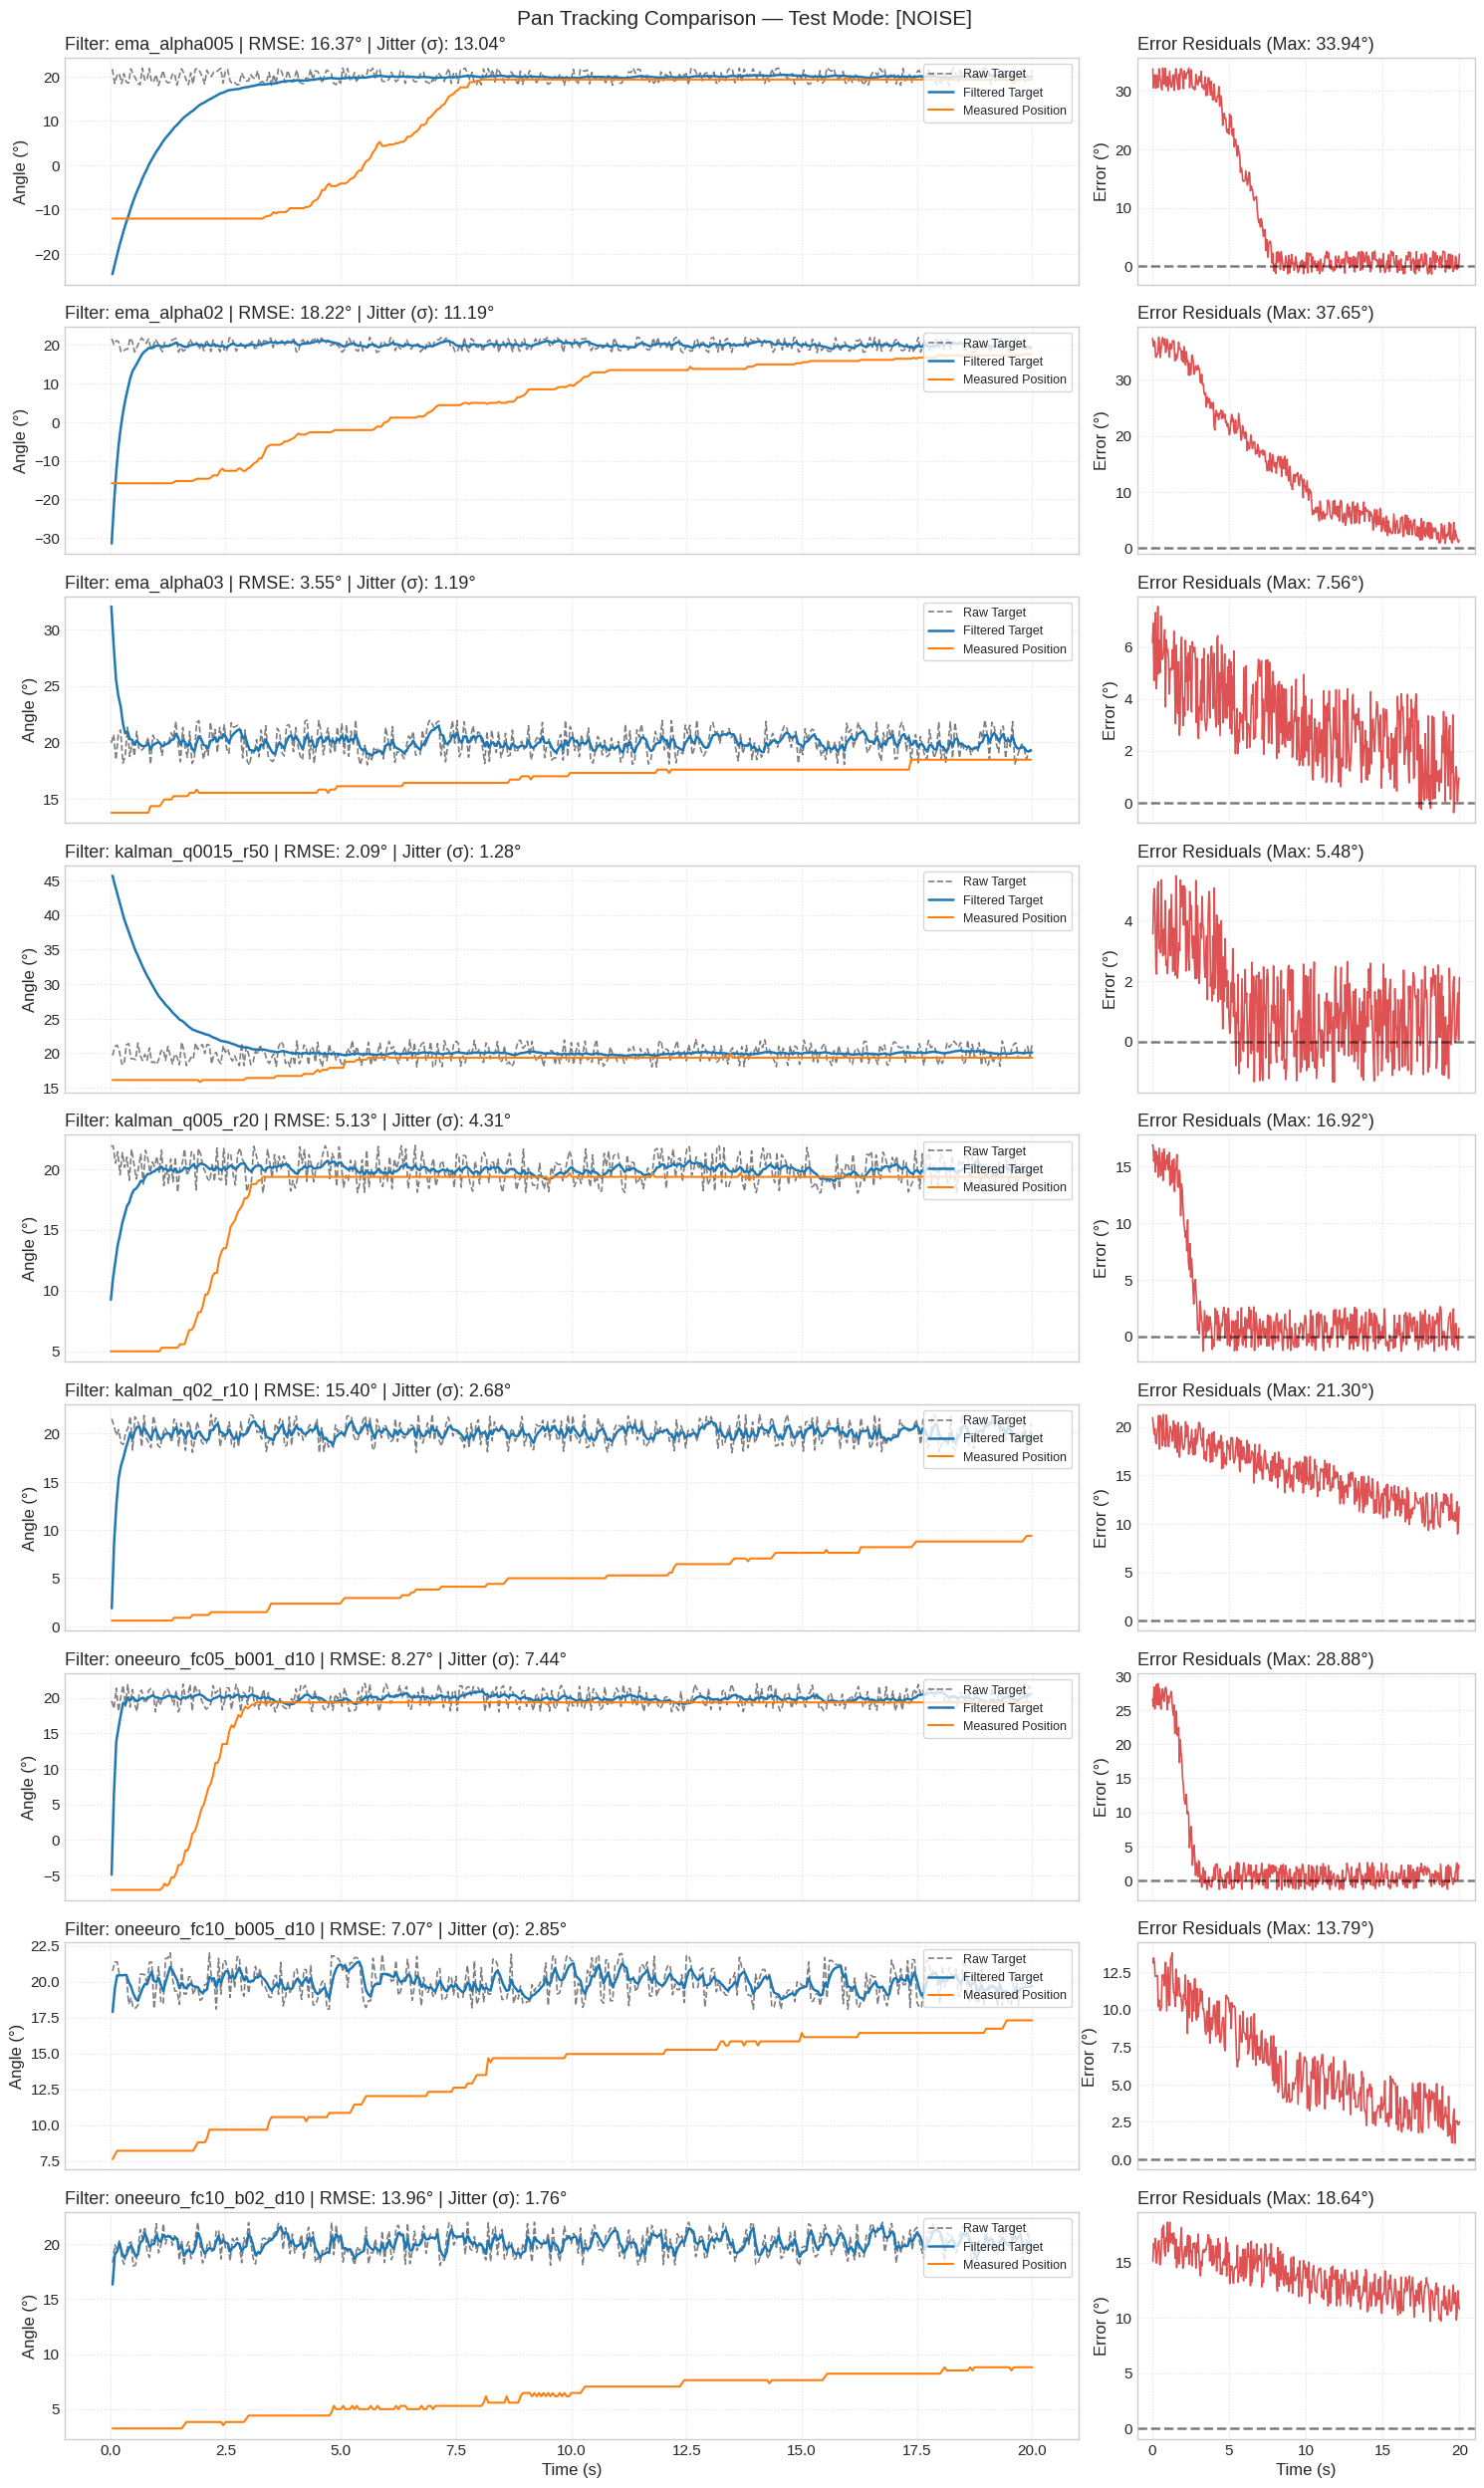

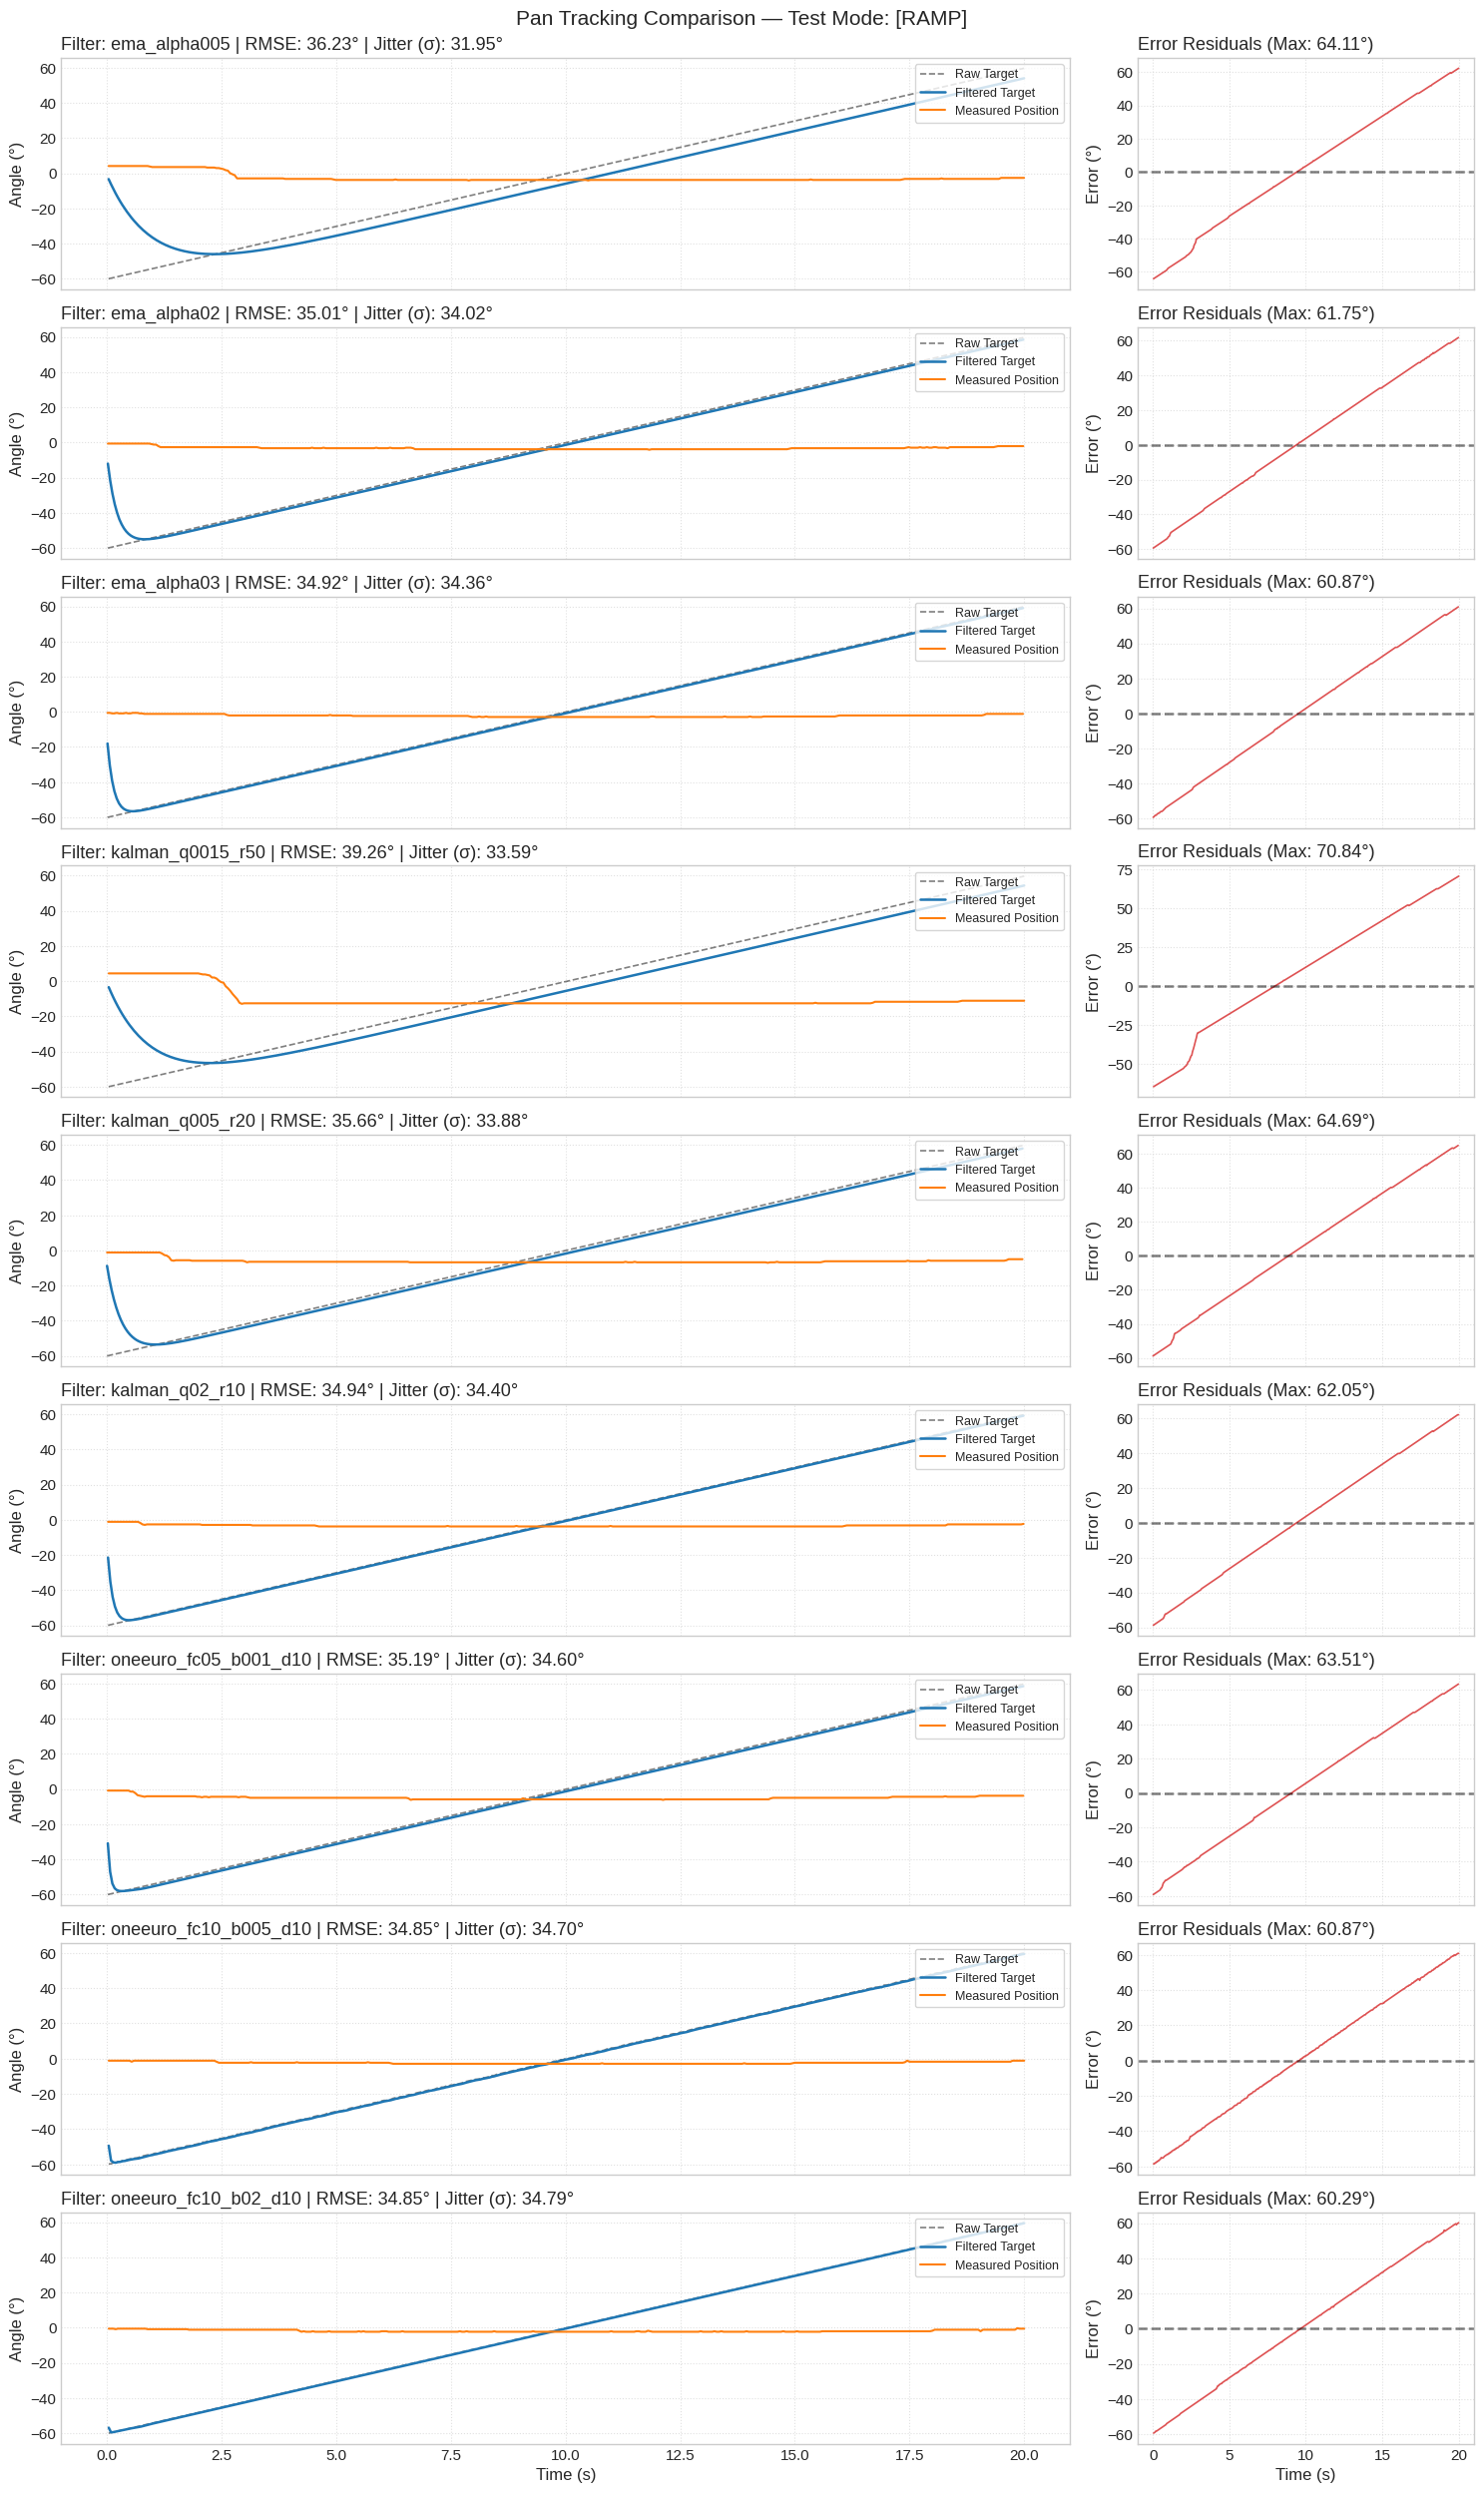

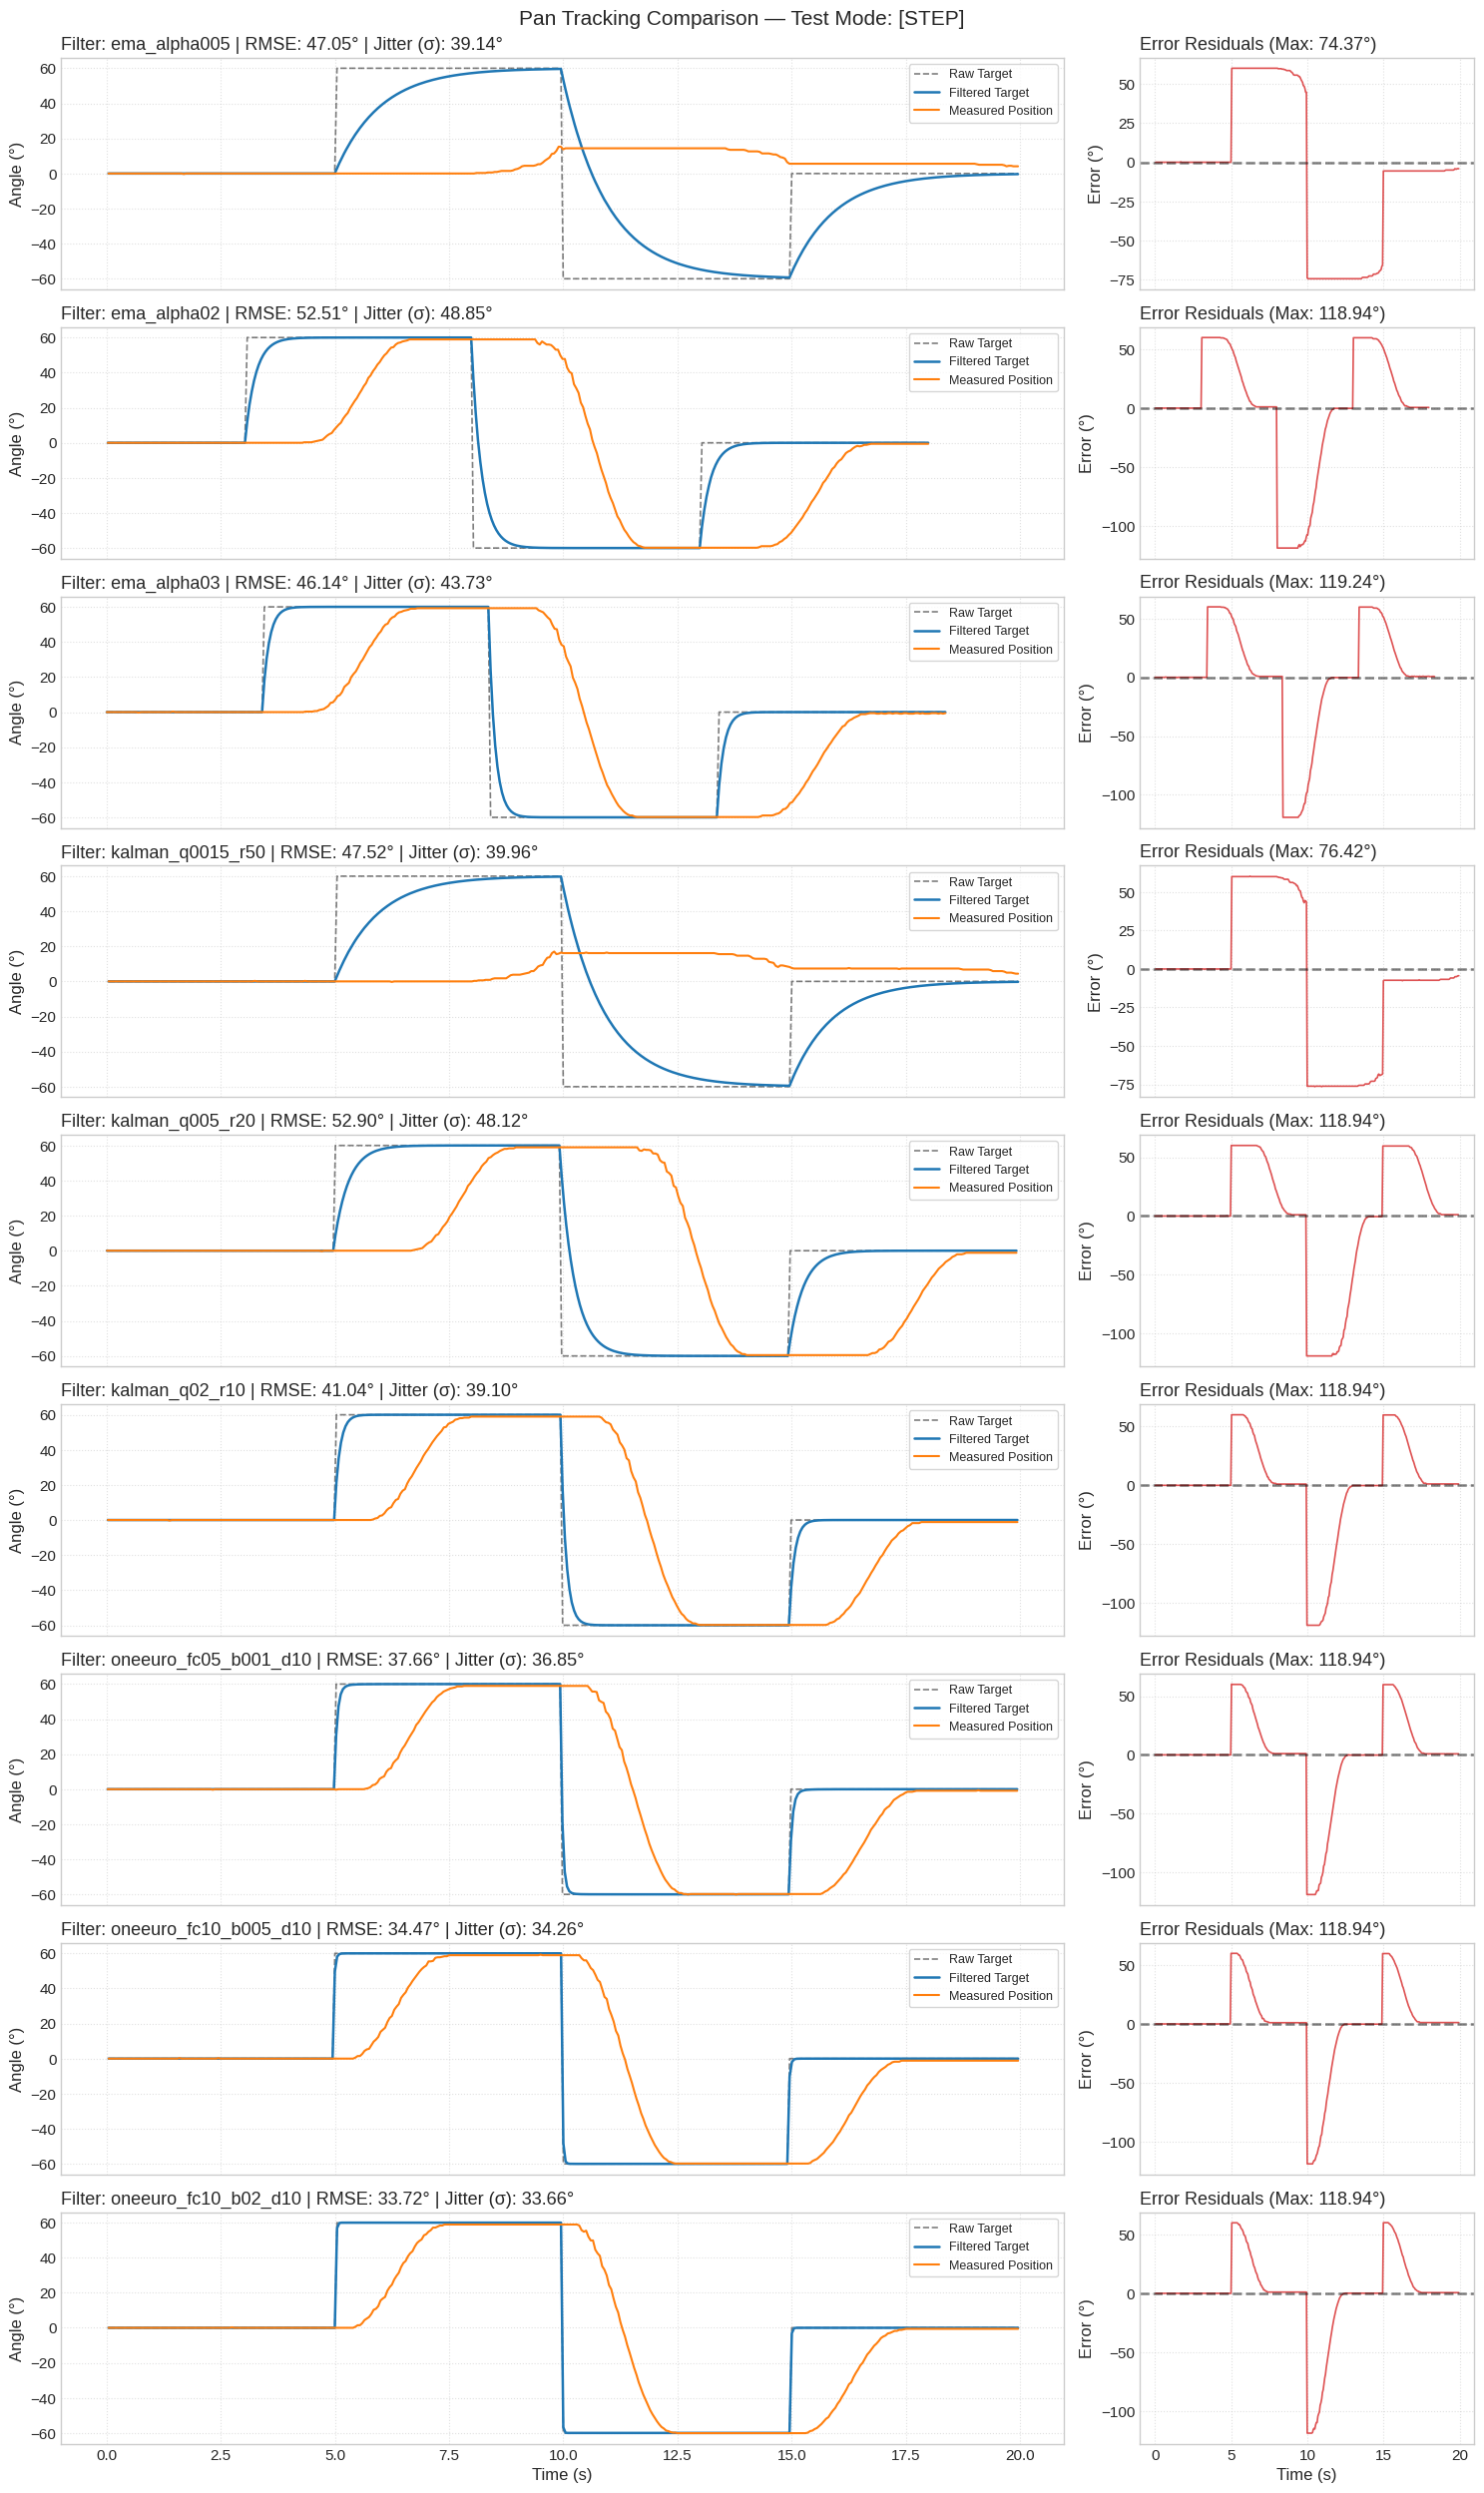

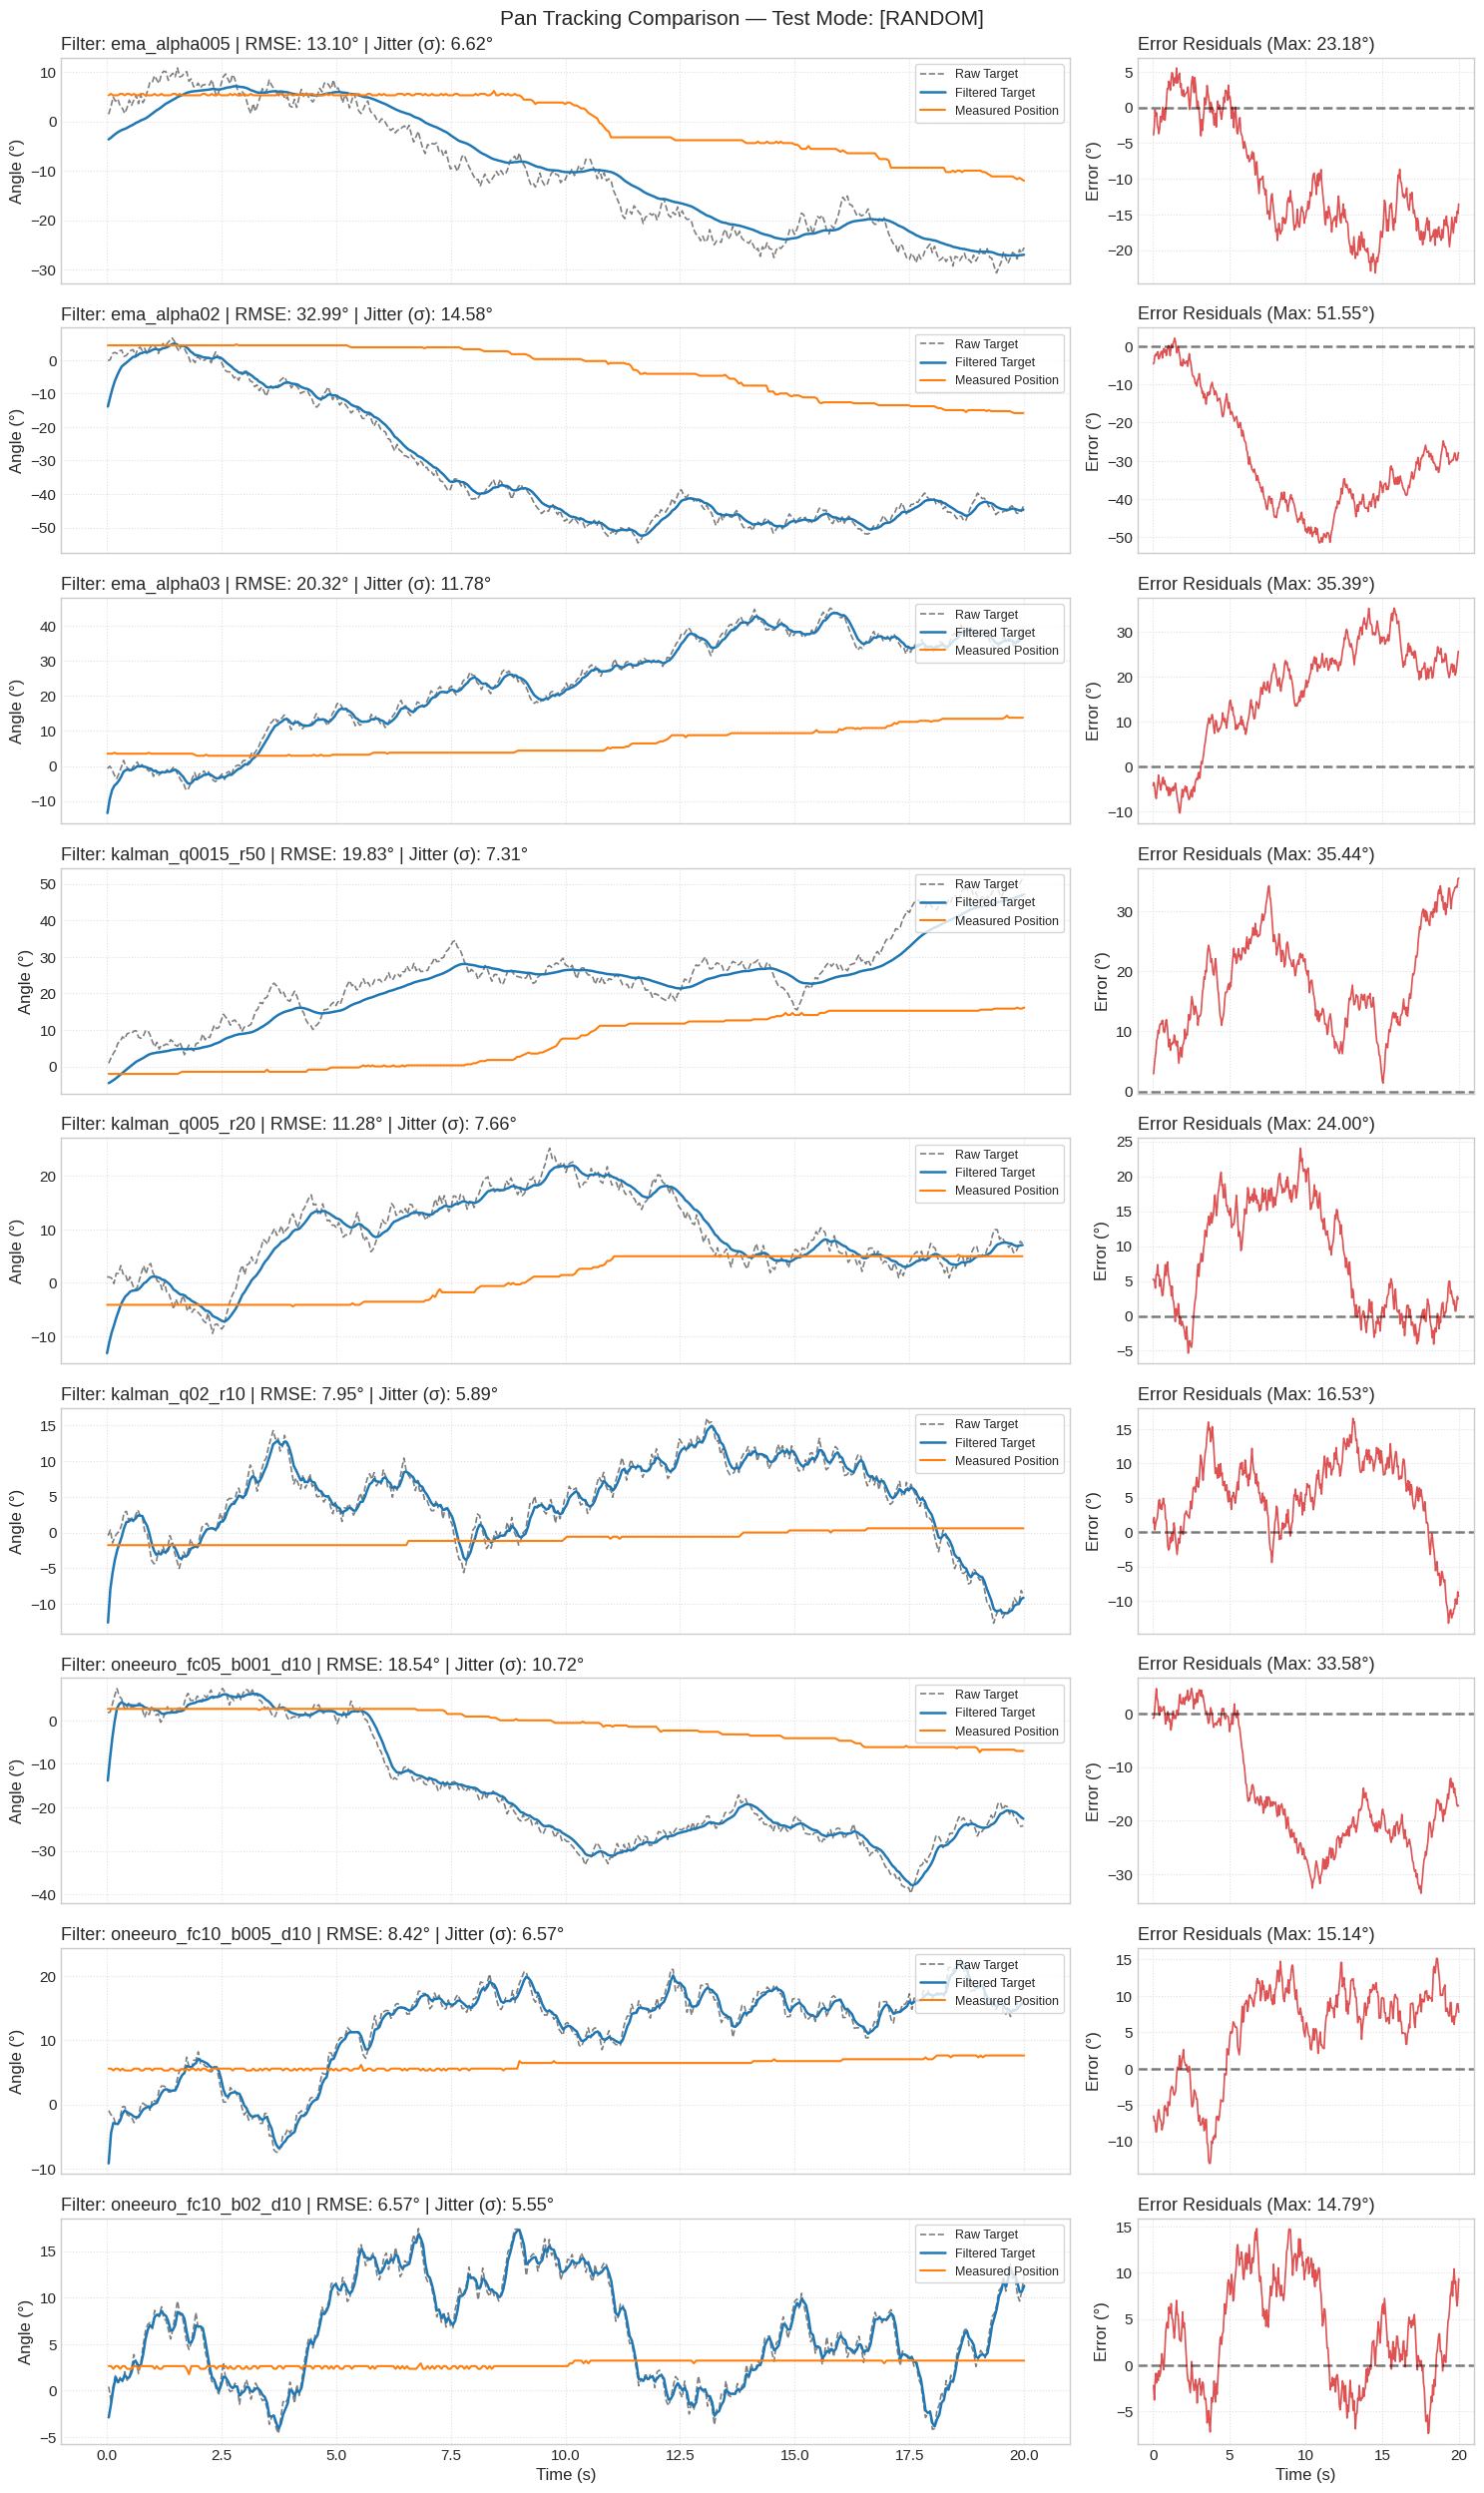

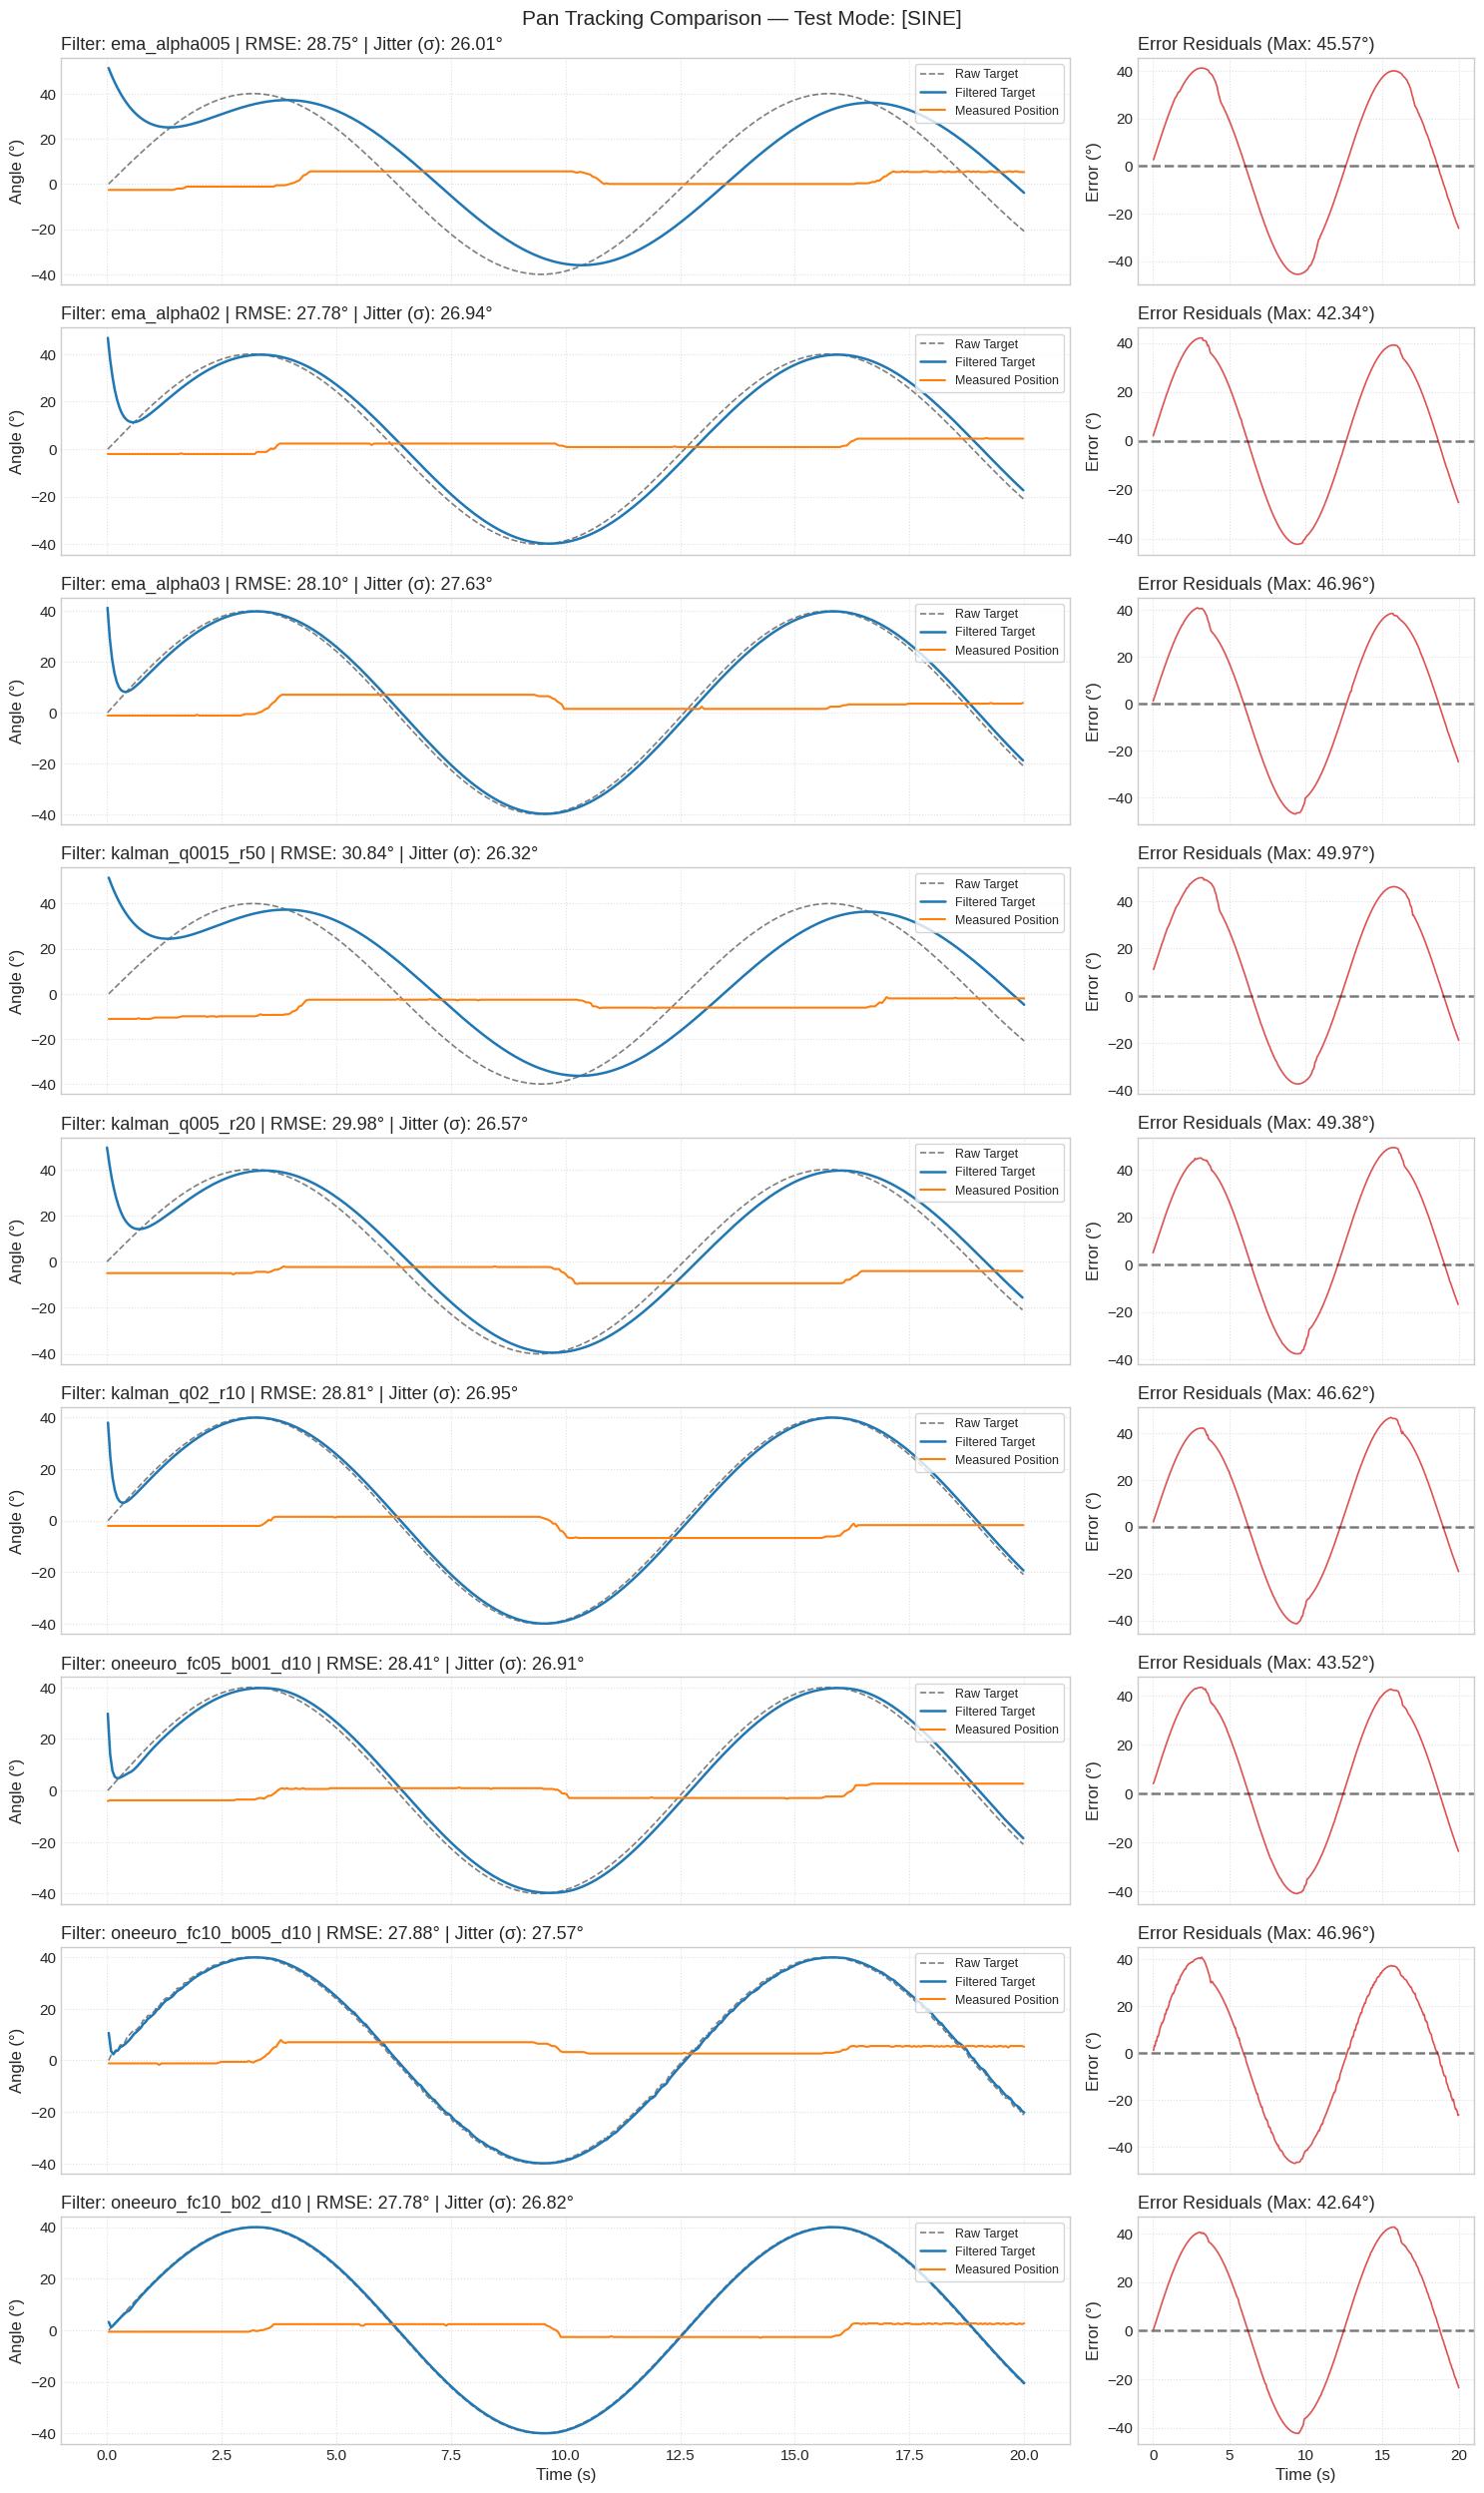

In [9]:
# --- Multi-Panel Time Domain Overlay Plots ---
unique_modes = summary_df['mode'].unique()

for mode in unique_modes:
    mode_data = summary_df[summary_df['mode'] == mode]
    num_controllers = len(mode_data)
    
    fig, axes = plt.subplots(num_controllers, 2, figsize=(15, 2.8 * num_controllers), 
                             gridspec_kw={'width_ratios': [3, 1]}, sharex='col')
    
    if num_controllers == 1:
        axes = np.array([axes])
        
    fig.suptitle(f"Pan Tracking Comparison — Test Mode: [{mode.upper()}]", fontsize=15, y=0.99)
    
    for idx, (_, row) in enumerate(mode_data.iterrows()):
        df = row['df']
        ctrl = row['controller']
        ax_track = axes[idx, 0]
        ax_err = axes[idx, 1]
        
        # Tracking curves
        ax_track.plot(df['time_s'], df['raw_pan'], 'k--', alpha=0.5, label='Raw Target', linewidth=1.2)
        ax_track.plot(df['time_s'], df['filtered_pan'], 'tab:blue', label='Filtered Target', linewidth=1.8)
        ax_track.plot(df['time_s'], df['measured_pan'], 'tab:orange', label='Measured Position', linewidth=1.5)
        
        ax_track.set_title(f"Filter: {ctrl} | RMSE: {row['RMSE']:.2f}° | Jitter (σ): {row['Jitter_Std']:.2f}°", loc='left')
        ax_track.set_ylabel("Angle (°)")
        ax_track.legend(loc='upper right', frameon=True, fontsize=9)
        ax_track.grid(True, linestyle=':', alpha=0.6)
        
        # Residual tracking error (Raw - Measured)
        error = df['raw_pan'] - df['measured_pan']
        ax_err.plot(df['time_s'], error, 'tab:red', linewidth=1.2, alpha=0.8)
        ax_err.axhline(0, color='k', linestyle='--', alpha=0.5)
        ax_err.set_title(f"Error Residuals (Max: {row['Peak_Error']:.2f}°)", loc='left')
        ax_err.set_ylabel("Error (°)")
        ax_err.grid(True, linestyle=':', alpha=0.6)
        
    axes[-1, 0].set_xlabel("Time (s)")
    axes[-1, 1].set_xlabel("Time (s)")
    plt.tight_layout()
    plt.show()

## Scoring

In [11]:
# --- Executive Filter Comparison Matrix ---
pivoted = summary_df.pivot(index='controller', columns='mode', values=['RMSE', 'Jitter_Std'])

scorecard = pd.DataFrame(index=pivoted.index)

# Aggregate Noise Jitter (from 'noise' or 'random_walk' test)
if 'noise' in pivoted['Jitter_Std'].columns:
    scorecard['Noise Suppression (σ)'] = pivoted['Jitter_Std']['noise']
else:
    scorecard['Noise Suppression (σ)'] = pivoted['Jitter_Std'].mean(axis=1)

# Dynamic Responsiveness (RMSE during 'step' or 'ramp')
if 'step' in pivoted['RMSE'].columns:
    scorecard['Step Responsiveness (RMSE)'] = pivoted['RMSE']['step']

if 'sine' in pivoted['RMSE'].columns:
    scorecard['Sine Tracking (RMSE)'] = pivoted['RMSE']['sine']

scorecard['Overall Mean RMSE'] = pivoted['RMSE'].mean(axis=1)

# Format & Display
display(scorecard.sort_values(by='Overall Mean RMSE')
        .style.format("{:.3f}°")
        .background_gradient(cmap='RdYlGn_r')
        .set_caption("Filter Benchmark Executive Summary (Lower is Better)"))

,Noise Suppression (σ),Step Responsiveness (RMSE),Sine Tracking (RMSE),Overall Mean RMSE
controller,,,,
oneeuro_fc10_b005_d10,2.847°,34.471°,27.884°,22.540°
oneeuro_fc10_b02_d10,1.764°,33.718°,27.781°,23.377°
oneeuro_fc05_b001_d10,7.442°,37.663°,28.407°,25.613°
kalman_q02_r10,2.681°,41.036°,28.806°,25.625°
ema_alpha03,1.187°,46.142°,28.095°,26.605°
kalman_q005_r20,4.307°,52.897°,29.983°,26.990°
kalman_q0015_r50,1.276°,47.521°,30.843°,27.911°
ema_alpha005,13.041°,47.045°,28.750°,28.298°
ema_alpha02,11.193°,52.510°,27.778°,33.301°
